# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [2]:
# 실습 준비 코드를 작성하세요.
# ----------------------------------------------------
# 1. 필요한 라이브러리 불러오기
# ----------------------------------------------------
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 2. 두 CSV 파일 불러오기
# ----------------------------------------------------
# 환경에 맞춰 경로를 지정하세요. (예: 'data/ravenstack_subscriptions.csv')
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

# ----------------------------------------------------
# 3. 각 데이터의 행과 열 개수, 상위 5개 행 확인
# ----------------------------------------------------
print("=== Subscriptions Data Shape & Head ===")
print("Shape:", subscriptions.shape)
display(subscriptions.head())

print("\n=== Feature Usage Data Shape & Head ===")
print("Shape:", feature_usage.shape)
display(feature_usage.head())

# ----------------------------------------------------
# 4. 분석 대상 컬럼의 자료형과 결측치 개수 확인
# ----------------------------------------------------
print("\n=== Subscriptions Info & Missing Values ===")
print(subscriptions.info())
print("\n[Subscriptions 결측치 개수]")
print(subscriptions.isnull().sum())

print("\n=== Feature Usage Info & Missing Values ===")
print(feature_usage.info())
print("\n[Feature Usage 결측치 개수]")
print(feature_usage.isnull().sum())

# ----------------------------------------------------
# 5. 날짜형으로 변환 (start_date, end_date, usage_date)
# ----------------------------------------------------
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print("\n변환 후 날짜 컬럼 타입 확인:")
print(f"- subscriptions['start_date']: {subscriptions['start_date'].dtype}")
print(f"- subscriptions['end_date']: {subscriptions['end_date'].dtype}")
print(f"- feature_usage['usage_date']: {feature_usage['usage_date'].dtype}")

# ----------------------------------------------------
# 6. subscription_id 기준으로 두 데이터 결합 (usage_with_sub)
# ----------------------------------------------------
# 기능 사용 이벤트를 기준으로 구독 정보를 연결하므로 inner join 수행
usage_with_sub = feature_usage.merge(
    subscriptions, on="subscription_id", how="inner"
)

print(f"\n결합된 usage_with_sub 행/열 개수: {usage_with_sub.shape}")
display(usage_with_sub.head())

# ----------------------------------------------------
# 7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록 개수 확인
# ----------------------------------------------------
# 시작일 이전 사용: usage_date < start_date
before_start_mask = usage_with_sub["usage_date"] < usage_with_sub["start_date"]
count_before_start = before_start_mask.sum()

# 종료일 이후 사용: end_date가 존재(notna)하면서 usage_date > end_date
after_end_mask = (
    usage_with_sub["end_date"].notna()
    & (usage_with_sub["usage_date"] > usage_with_sub["end_date"])
)
count_after_end = after_end_mask.sum()

print("\n=== 비유효 기능 사용 기록 건수 확인 ===")
print(f"1. 구독 시작 전 사용 기록 수 (usage_date < start_date): {count_before_start:,}건")
print(f"2. 구독 종료 후 사용 기록 수 (usage_date > end_date): {count_after_end:,}건")
print(f"3. 총 비정상/비유효 사용 기록 수: {(count_before_start + count_after_end):,}건")

# ----------------------------------------------------
# 8. 유효 기능 사용 조건을 적용한 valid_usage 생성
# ----------------------------------------------------
# 조건: usage_date >= start_date AND (end_date가 null이거나 usage_date <= end_date)
valid_condition = (
    usage_with_sub["usage_date"] >= usage_with_sub["start_date"]
) & (
    usage_with_sub["end_date"].isna()
    | (usage_with_sub["usage_date"] <= usage_with_sub["end_date"])
)

valid_usage = usage_with_sub[valid_condition].copy()

print("\n=== 유효 기능 사용 데이터(valid_usage) 생성 완료 ===")
print(f"필터링 전 전체 행 수: {len(usage_with_sub):,}건")
print(f"필터링 후 유효 행 수: {len(valid_usage):,}건")
print(f"제외된 행 수: {(len(usage_with_sub) - len(valid_usage)):,}건")

=== Subscriptions Data Shape & Head ===
Shape: (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



=== Feature Usage Data Shape & Head ===
Shape: (25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



=== Subscriptions Info & Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 376.1 KB
None

[Subscriptions 결측치 개수]
subscription_id         0
account_id 

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,...,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,2024-11-23,...,Pro,67,3283,39396,False,False,False,False,annual,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,2023-09-22,...,Basic,30,570,6840,False,True,False,False,annual,True
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,2024-10-15,...,Basic,22,418,5016,False,False,False,False,annual,True
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,2024-11-24,...,Basic,41,779,9348,False,False,False,False,annual,True
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,...,Basic,18,342,4104,False,False,False,False,monthly,True



=== 비유효 기능 사용 기록 건수 확인 ===
1. 구독 시작 전 사용 기록 수 (usage_date < start_date): 19,142건
2. 구독 종료 후 사용 기록 수 (usage_date > end_date): 290건
3. 총 비정상/비유효 사용 기록 수: 19,432건

=== 유효 기능 사용 데이터(valid_usage) 생성 완료 ===
필터링 전 전체 행 수: 25,000건
필터링 후 유효 행 수: 5,568건
제외된 행 수: 19,432건


---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?

#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

=== 2024년 1월~6월 코호트 리텐션 테이블 (백분율) ===


month_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2024-01,100.0%,15.1%,16.4%,19.2%,20.5%,16.4%,19.2%
2024-02,100.0%,21.3%,16.9%,15.7%,7.9%,23.6%,28.1%
2024-03,100.0%,22.4%,22.4%,20.6%,19.6%,10.3%,21.5%
2024-04,100.0%,17.9%,27.4%,19.8%,19.8%,16.0%,15.1%
2024-05,100.0%,18.2%,19.7%,16.8%,21.2%,19.7%,15.3%
2024-06,100.0%,28.0%,12.0%,16.0%,20.0%,15.3%,21.3%


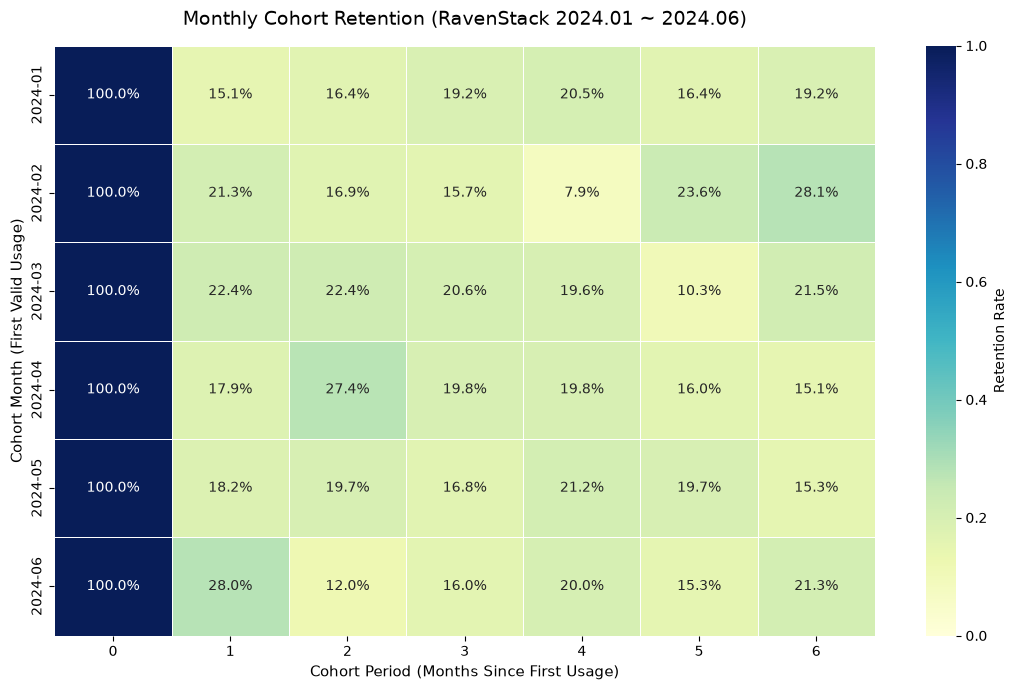


[Month 1 리텐션 비교 결과]
- 최고 리텐션 코호트: 2024-06 (28.00%)
- 최저 리텐션 코호트: 2024-01 (15.07%)


In [3]:
# 필수 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ----------------------------------------------------
# 1. activity_month 생성 (사용 월을 매월 1일 기준 Timestamp로 변환)
# ----------------------------------------------------
valid_usage["activity_month"] = valid_usage["usage_date"].dt.to_period("M")

# ----------------------------------------------------
# 2. 구독별 첫 activity_month를 구해 cohort_month로 추가
# ----------------------------------------------------
first_activity = (
    valid_usage.groupby("subscription_id")["activity_month"]
    .min()
    .reset_index()
)
first_activity.rename(columns={"activity_month": "cohort_month"}, inplace=True)

# 원본 valid_usage에 cohort_month 병합
valid_usage = valid_usage.merge(
    first_activity, on="subscription_id", how="left"
)

# ----------------------------------------------------
# 3. month_index 계산 (activity_month - cohort_month 개월 수 차이)
# ----------------------------------------------------
valid_usage["month_index"] = (
    valid_usage["activity_month"].dt.year
    - valid_usage["cohort_month"].dt.year
) * 12 + (
    valid_usage["activity_month"].dt.month
    - valid_usage["cohort_month"].dt.month
)

# ----------------------------------------------------
# 4. 코호트별 최초 고유 구독 수 (cohort_sizes) 계산
# ----------------------------------------------------
cohort_sizes = (
    first_activity.groupby("cohort_month")["subscription_id"]
    .nunique()
    .rename("cohort_size")
)

# ----------------------------------------------------
# 5. cohort_month와 month_index별 고유 구독 수 집계
# ----------------------------------------------------
cohort_counts = (
    valid_usage.groupby(["cohort_month", "month_index"])["subscription_id"]
    .nunique()
    .unstack()
)

# ----------------------------------------------------
# 6. retention_table 생성 (고유 구독 수 ÷ cohort_sizes)
# ----------------------------------------------------
retention_table = cohort_counts.divide(cohort_sizes, axis=0)

# ----------------------------------------------------
# 7. 2024년 1월~6월 코호트 및 Month 0~6 선택 및 백분율 출력
# ----------------------------------------------------
target_cohorts = [
    pd.Period(f"2024-{str(m).zfill(2)}", "M") for m in range(1, 7)
]
target_months = list(range(0, 7))

# 대상 기간 필터링 및 reindex
filtered_retention = retention_table.reindex(
    index=target_cohorts, columns=target_months
)

print("=== 2024년 1월~6월 코호트 리텐션 테이블 (백분율) ===")
display(filtered_retention.style.format("{:.1%}"))

# ----------------------------------------------------
# 8. 리텐션 히트맵 시각화
# ----------------------------------------------------
plt.figure(figsize=(11, 7))
sns.heatmap(
    filtered_retention,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": "Retention Rate"},
    linewidths=0.5,
)

plt.title(
    "Monthly Cohort Retention (RavenStack 2024.01 ~ 2024.06)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Cohort Period (Months Since First Usage)", fontsize=11)
plt.ylabel("Cohort Month (First Valid Usage)", fontsize=11)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 9. 1월~6월 코호트 중 Month 1 리텐션 최고/최저 코호트 탐색
# ----------------------------------------------------
month1_retention = filtered_retention[1].dropna()
max_cohort = month1_retention.idxmax()
min_cohort = month1_retention.idxmin()

print(
    f"\n[Month 1 리텐션 비교 결과]\n"
    f"- 최고 리텐션 코호트: {max_cohort} ({month1_retention[max_cohort]:.2%})\n"
    f"- 최저 리텐션 코호트: {min_cohort} ({month1_retention[min_cohort]:.2%})"
)

### 필수 1 답변 작성란

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요? 
- 분석 목적이 제품의 핵심 기능을 처음 사용한 뒤 다시 사용하는지를 확인하는 것이기 때문.
- 실제 가치 경험의 시작점을 비교할 수 있음

**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
- 기준이되는 첫 번 째 달이기 때문

**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
- 가장 높은 코호트는 2024년 6월(28%) / 가장 낮은 코호트는 2024년 1월(15%)

**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?
- 네. 각 월에 기능을 사용했는지 따로 계산하기 때문에, 한 달 건너 뛰고 다시 돌아온 구독이 있으면
- N개월 뒤에서도 높아질 수 있다.

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

전체 코호트 모수 (cohort_base): 2,651개 구독


,subscription_id,cohort_month,plan_tier
0,S-f9b1d0,2024-05,Basic
1,S-3673f2,2024-08,Enterprise
2,S-813cdc,2023-07,Pro
3,S-6c969d,2024-05,Basic
4,S-810c27,2024-10,Basic


2024년 1~6월 대상 모수 (selected_base): 662개 구독

=== 요금제별 Month 1 리텐션 결과 (낮은 순) ===


,total_subscriptions,retained_m1_subscriptions,retention_rate
plan_tier,,,
Basic,223,42,18.83%
Pro,219,48,21.92%
Enterprise,220,50,22.73%


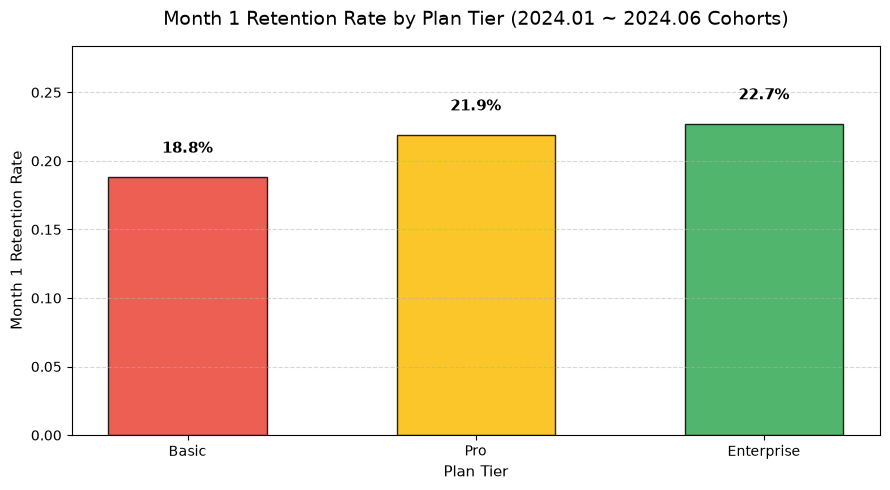


최저 Month 1 리텐션 요금제: Basic (18.83%)


In [4]:
# 필수 2 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1. 구독별 cohort_month, plan_tier를 정리한 cohort_base 생성
# ----------------------------------------------------
# valid_usage에서 각 구독(subscription_id)별 첫 사용 월(cohort_month)과 요금제(plan_tier) 추출
cohort_base = (
    valid_usage[["subscription_id", "cohort_month", "plan_tier"]]
    .drop_duplicates(subset=["subscription_id"])
    .reset_index(drop=True)
)

print(f"전체 코호트 모수 (cohort_base): {len(cohort_base):,}개 구독")
display(cohort_base.head())

# ----------------------------------------------------
# 2. 2024년 1월~6월 코호트만 선택하여 selected_base에 저장
# ----------------------------------------------------
target_cohorts = [
    pd.Period(f"2024-{str(m).zfill(2)}", "M") for m in range(1, 7)
]
selected_base = cohort_base[
    cohort_base["cohort_month"].isin(target_cohorts)
].copy()

print(f"2024년 1~6월 대상 모수 (selected_base): {len(selected_base):,}개 구독")

# ----------------------------------------------------
# 3. 요금제별 코호트 구독 수 계산
# ----------------------------------------------------
cohort_sizes_by_plan = (
    selected_base.groupby("plan_tier")["subscription_id"]
    .nunique()
    .rename("total_subscriptions")
)

# ----------------------------------------------------
# 4. month_index == 1 인 기록을 이용해 요금제별 Month 1 재사용 구독 수 계산
# ----------------------------------------------------
# 2024년 1~6월 코호트에 속하면서 정확히 1개월 뒤(month_index == 1)에 재사용한 구독자 필터링
m1_active_subs = set(
    valid_usage[
        (valid_usage["cohort_month"].isin(target_cohorts))
        & (valid_usage["month_index"] == 1)
    ]["subscription_id"]
)

# selected_base 중에서 실제 M1에 재사용한 구독자만 필터링 후 요금제별 집계
m1_users_base = selected_base[
    selected_base["subscription_id"].isin(m1_active_subs)
]
m1_counts_by_plan = (
    m1_users_base.groupby("plan_tier")["subscription_id"]
    .nunique()
    .rename("retained_m1_subscriptions")
)

# ----------------------------------------------------
# 5~6. plan_retention 생성, 정렬 및 백분율 출력
# ----------------------------------------------------
plan_retention = pd.concat(
    [cohort_sizes_by_plan, m1_counts_by_plan], axis=1
).fillna(0)
plan_retention["retention_rate"] = (
    plan_retention["retained_m1_subscriptions"]
    / plan_retention["total_subscriptions"]
)

# Month 1 리텐션이 낮은 순서로 정렬
plan_retention = plan_retention.sort_values(
    by="retention_rate", ascending=True
)

print("\n=== 요금제별 Month 1 리텐션 결과 (낮은 순) ===")
# jinja2 없이도 안전하게 백분율 문자열 포맷팅
display_df = plan_retention.copy()
display_df["retention_rate"] = display_df["retention_rate"].map(
    lambda x: f"{x:.2%}"
)
display(display_df)

# ----------------------------------------------------
# 7. 요금제별 Month 1 리텐션 막대그래프 시각화
# ----------------------------------------------------
plt.figure(figsize=(9, 5))
bars = plt.bar(
    plan_retention.index,
    plan_retention["retention_rate"],
    color=["#EA4335", "#FBBC05", "#34A853"],
    edgecolor="black",
    width=0.55,
    alpha=0.85,
)

plt.title(
    "Month 1 Retention Rate by Plan Tier (2024.01 ~ 2024.06 Cohorts)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Plan Tier", fontsize=11)
plt.ylabel("Month 1 Retention Rate", fontsize=11)
plt.ylim(0, max(plan_retention["retention_rate"]) * 1.25)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 각 막대 위에 백분율 레이블 표기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.015,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

# 최저 요금제 출력
lowest_plan = plan_retention.index[0]
lowest_rate = plan_retention.loc[lowest_plan, "retention_rate"]
print(f"\n최저 Month 1 리텐션 요금제: {lowest_plan} ({lowest_rate:.2%})")

### 필수 2 답변 작성란

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
- 고객의 계약 요금제라는 특성을 기준으로 나누었다(속성 기반 세그멘테이션)

**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
- Basic (18.83%)

**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
- 세그먼트별 구체적인 개선사항 도출 가능

**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?
- 아니오. 요금제 차이는 리텐션이 낮게 나타난 그룹의 속성일 뿐, 실제 원인은 아닙니다. 다른 변수들이 복합적으로 얽혀있을 수 있습니다.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

전체 코호트 모수: 2,651개 구독


,subscription_id,cohort_month,billing_frequency
0,S-f9b1d0,2024-05,monthly
1,S-3673f2,2024-08,annual
2,S-813cdc,2023-07,annual
3,S-6c969d,2024-05,monthly
4,S-810c27,2024-10,annual


데이터 내 최대 활동 월: 2024-12
2024-06 코호트의 Month 3 도달 시점: 2024-09 (2024-09)
-> 2024년 1월~6월 코호트 모두 Month 3까지 온전히 관찰 가능합니다.

=== [결과 1] 코호트·결제 주기별 최초 모수 및 Month 1~3 재사용 구독 수 ===


cohort_size  Month 1  Month 2  Month 3
cohort_month billing_frequency                                        
2024-01      annual                      46        6        7       10
             monthly                     27        5        5        4
2024-02      annual                      39       10        5        4
             monthly                     50        9       10       10
2024-03      annual                      55       11       11       11
             monthly                     52       13       13       11
2024-04      annual                      49        8       13        8
             monthly                     57       11       16       13
2024-05      annual                      68       15       14       11
             monthly                     69       10       13       12
2024-06      annual                      67       20        9       13
             monthly                     83       22        9       11


=== [결과 2] billing_retention 표 (백분율) ===


Month 1 Month 2 Month 3
cohort_month billing_frequency                        
2024-01      annual             13.04%  15.22%  21.74%
             monthly            18.52%  18.52%  14.81%
2024-02      annual             25.64%  12.82%  10.26%
             monthly            18.00%  20.00%  20.00%
2024-03      annual             20.00%  20.00%  20.00%
             monthly            25.00%  25.00%  21.15%
2024-04      annual             16.33%  26.53%  16.33%
             monthly            19.30%  28.07%  22.81%
2024-05      annual             22.06%  20.59%  16.18%
             monthly            14.49%  18.84%  17.39%
2024-06      annual             29.85%  13.43%  19.40%
             monthly            26.51%  10.84%  13.25%

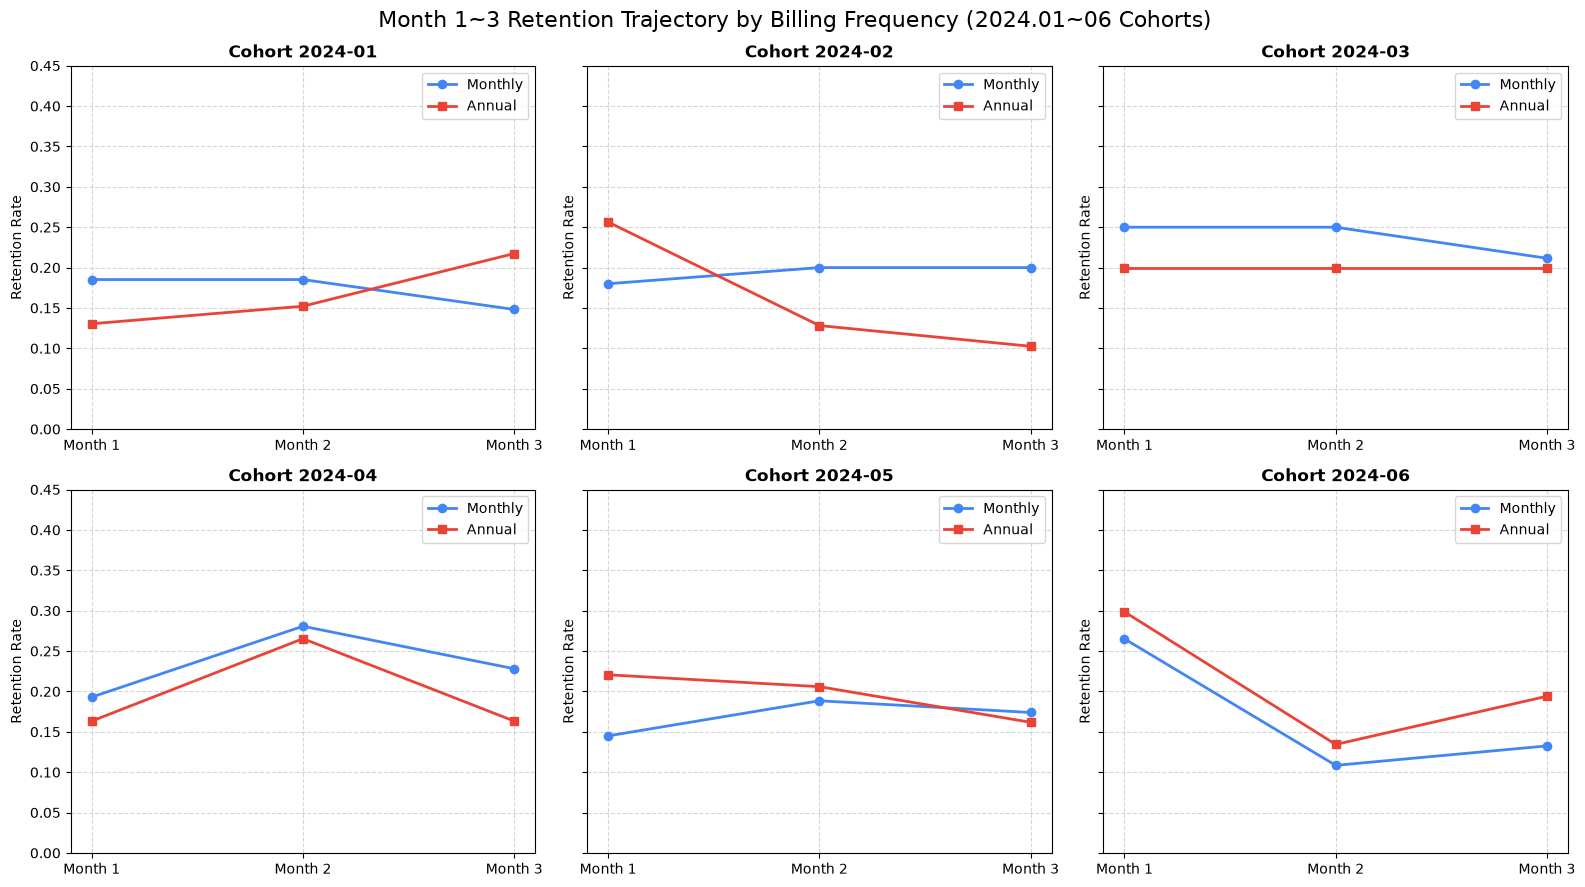


=== [결과 3-1] 각 코호트별 Month 1 결제 주기 간 리텐션 차이 (%p) ===


,"M1_Diff(Monthly - Annual, %p)"
cohort_month,
2024-01,+5.48%p
2024-02,-7.64%p
2024-03,+5.00%p
2024-04,+2.97%p
2024-05,-7.57%p
2024-06,-3.34%p



=== [결과 3-2] 경과 월별 변화폭 (%p) ===


M1_to_M2_change(%p) M2_to_M3_change(%p)
cohort_month billing_frequency                                        
2024-01      annual                        +2.17%p             +6.52%p
             monthly                       +0.00%p             -3.70%p
2024-02      annual                       -12.82%p             -2.56%p
             monthly                       +2.00%p             +0.00%p
2024-03      annual                        +0.00%p             +0.00%p
             monthly                       +0.00%p             -3.85%p
2024-04      annual                       +10.20%p            -10.20%p
             monthly                       +8.77%p             -5.26%p
2024-05      annual                        -1.47%p             -4.41%p
             monthly                       +4.35%p             -1.45%p
2024-06      annual                       -16.42%p             +5.97%p
             monthly                      -15.66%p             +2.41%p

In [5]:
# 과제 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# 1. 구독별 cohort_month, billing_frequency 정리 (cohort_base)
# ====================================================
# valid_usage에서 각 구독의 첫 유효 기능 사용 월(cohort_month)과 결제 주기(billing_frequency) 추출
cohort_base = (
    valid_usage[["subscription_id", "cohort_month", "billing_frequency"]]
    .drop_duplicates(subset=["subscription_id"])
    .reset_index(drop=True)
)

print(f"전체 코호트 모수: {len(cohort_base):,}개 구독")
display(cohort_base.head())

# ====================================================
# 2. 2024년 1월~6월 코호트 선택 및 관찰 가능 여부 확인
# ====================================================
target_cohorts = [
    pd.Period(f"2024-{str(m).zfill(2)}", "M") for m in range(1, 7)
]
selected_base = cohort_base[
    cohort_base["cohort_month"].isin(target_cohorts)
].copy()

max_data_month = valid_usage["activity_month"].max()
print(f"데이터 내 최대 활동 월: {max_data_month}")
print(
    f"2024-06 코호트의 Month 3 도달 시점: {pd.Period('2024-06', 'M') + 3} (2024-09)"
)
print("-> 2024년 1월~6월 코호트 모두 Month 3까지 온전히 관찰 가능합니다.\n")

# ====================================================
# 3. 코호트·결제 주기별 최초 구독 수(분모) 및 Month 1~3 고유 재사용 구독 수(분자) 계산
# ====================================================
# 분모: 코호트·결제 주기별 최초 구독 수
cohort_sizes = (
    selected_base.groupby(["cohort_month", "billing_frequency"])[
        "subscription_id"
    ]
    .nunique()
    .rename("cohort_size")
)

# 분자: valid_usage에서 target_cohorts 대상, Month 1, 2, 3 재사용 구독자 집계
# (한 구독이 같은 달에 여러 번 사용해도 nunique로 1회만 집계)
valid_m123 = valid_usage[
    (valid_usage["cohort_month"].isin(target_cohorts))
    & (valid_usage["month_index"].isin([1, 2, 3]))
]

monthly_reused = (
    valid_m123.groupby(["cohort_month", "billing_frequency", "month_index"])[
        "subscription_id"
    ]
    .nunique()
    .unstack(level="month_index")
)

# 컬럼명 명확화 (1 -> M1, 2 -> M2, 3 -> M3)
monthly_reused.columns = ["Month 1", "Month 2", "Month 3"]

# 고유 재사용 구독 수와 최초 모수 결합 표 출력
counts_summary = pd.concat([cohort_sizes, monthly_reused], axis=1)
print("=== [결과 1] 코호트·결제 주기별 최초 모수 및 Month 1~3 재사용 구독 수 ===")
display(counts_summary)

# ====================================================
# 4~5. billing_retention 생성 및 백분율 출력
# ====================================================
# 리텐션 = 해당 경과 월의 고유 재사용 구독 수 / 해당 그룹의 최초 구독 수
billing_retention = monthly_reused.divide(cohort_sizes, axis=0)

print("\n=== [결과 2] billing_retention 표 (백분율) ===")
# jinja2 없이도 깔끔하게 백분율로 출력
display_retention = billing_retention.map(
    lambda x: f"{x:.2%}" if pd.notna(x) else ""
)
display(display_retention)

# ====================================================
# 6. 코호트별 월간 vs 연간 Month 1~3 리텐션 비교 선그래프 시각화
# ====================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()
months_labels = ["Month 1", "Month 2", "Month 3"]

for i, cohort in enumerate(target_cohorts):
    ax = axes[i]
    if (cohort, "monthly") in billing_retention.index:
        ax.plot(
            months_labels,
            billing_retention.loc[(cohort, "monthly"), months_labels],
            marker="o",
            linewidth=2,
            color="#4285F4",
            label="Monthly",
        )
    if (cohort, "annual") in billing_retention.index:
        ax.plot(
            months_labels,
            billing_retention.loc[(cohort, "annual"), months_labels],
            marker="s",
            linewidth=2,
            color="#EA4335",
            label="Annual",
        )

    ax.set_title(f"Cohort {cohort}", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 0.45)  # 리텐션 분포 범위에 맞게 설정
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_ylabel("Retention Rate")
    ax.legend(loc="upper right")

plt.suptitle(
    "Month 1~3 Retention Trajectory by Billing Frequency (2024.01~06 Cohorts)",
    fontsize=16,
    y=0.98,
)
plt.tight_layout()
plt.show()

# ====================================================
# 7. 결제 주기 간 차이(Month 1) 및 경과 월별 변화폭(%p) 계산
# ====================================================
# 1) Month 1 결제 주기 간 차이 (Monthly - Annual)
unstacked_m1 = billing_retention["Month 1"].unstack(level="billing_frequency")
diff_m1 = (
    (unstacked_m1["monthly"] - unstacked_m1["annual"]) * 100
).rename("M1_Diff(Monthly - Annual, %p)")

# 2) 각 결제 주기별 Month 1->2, Month 2->3 변화폭 (%p)
retention_pct = billing_retention * 100
changes_df = pd.DataFrame(index=billing_retention.index)
changes_df["M1_to_M2_change(%p)"] = (
    retention_pct["Month 2"] - retention_pct["Month 1"]
)
changes_df["M2_to_M3_change(%p)"] = (
    retention_pct["Month 3"] - retention_pct["Month 2"]
)

print("\n=== [결과 3-1] 각 코호트별 Month 1 결제 주기 간 리텐션 차이 (%p) ===")
display(diff_m1.to_frame().map(lambda x: f"{x:+.2f}%p"))

print("\n=== [결과 3-2] 경과 월별 변화폭 (%p) ===")
display(changes_df.map(lambda x: f"{x:+.2f}%p" if pd.notna(x) else ""))

### 과제 1 답변 작성란

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?
- 코호트1: annual 5.48%p | 코호트2: monthly 7.64%p | 코호트3: annual 5%p | 코호트4: annual 2.97%p | 코호트5: monthly 7.57%p | 코호트6: monthly 3.34%p

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?
코호트 1 | 코호트2 | 코호트3 | 코호트4 | 코호트5 | 코호트6 |
| --- | --- | --- | --- | --- | --- |
annual <br> +2.17%p -> +6.52%p |  annual <br>-12.82%p -> -2.56%p |  annual<br> +0.00%p -> +0.00%p |  annual<br> +10.20%p -> -10.20%p |  annual<br> -1.47%p -> -4.41%p |  annual<br> -16.42%p -> +5.97%p
monthly<br> +0.00%p -> -3.70%p | monthly<br> +2.00%p -> +0.00%p |  monthly<br> +0.00%p -> -3.85%p | monthly<br> +8.77%p -> -5.62%p | monthly<br> +4.35%p -> -1.45%p |  monthly<br> -15.66%p -> +2.41%p
- M1 to M2 : 완만한 감소 패턴
- M2 to M3 : 안정화 및 반등

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.
- 코호트2의 annual이다. M1 to M2구간에서 retention이 -12.82%p로 저조한데다가, M2 to M3구간에서도 반등하지 못하고 추가 감소하였다.
- 원인 가설: 해당 코호트의 고객들이 계속 상품을 이용할만한 메리트를 제공하지 못했거나, 이용 과정에서 오류 발생률이 높았을 수 있다.
- 개선 방향: Day 30~60 집중 케어 - 이탈 방지를 위한 사용방법 추가 안내, 오류 처리 집중 등

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?
- 아니오. 결제주기와 리텐션의 인과를 증명할 수는 없다. 해당 구간에 어떤 이슈가 있었는지 내부/외부적 요인을 검토해야한다.

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?
- 구독별 첫 유효 기능 사용 월을 출발점으로 했다.

2. 월간 N개월 리텐션은 어떻게 계산했나요?
- 첫 기능 사용월로부터 N개월 뒤 기능을 다시 사용한 고유 구독 수를 해당 코호트의 최초 구독수로 나누었다.

3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?
- 같은 시기에 기능을 사용한 사용자 중에서도 어떤 특성의 그룹에서 유지(재방문율, 재구매율)이 낮은지 구체적으로 확인할 수 있다.

4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?
- Basic, 18.8%정도로 가장 낮았다.

5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?
- 리텐션 표는 어느 그룹이 낮은지는 보여주지만 요금제, 기능 경험, 고객 특성 중 무엇이 원인인지는 직접적으로 알려주지 않기 떄문에.